# MFAA Chapter 14 Laboratory
**Optimal Exit Solver** (book §14.9)

A general solver for stopping, switching, and constrained problems, with the verification checklist as a certification layer. Seed `20261400`.

In [1]:
import sys, numpy as np, matplotlib.pyplot as plt
sys.path.insert(0,'..')
from engine import ch14
from dataclasses import replace

## 1. The development option: value surface and free boundary
V* = 2.366K at ρ=6%, δ=4%, σ=0.20 — the closed-form audit case.

V* grid 2.365 vs closed form 2.366


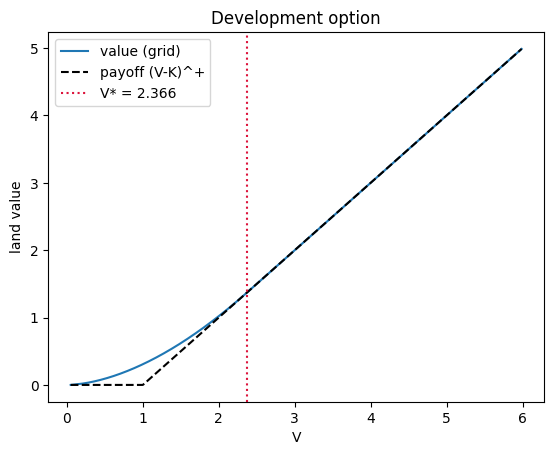

In [2]:
p = ch14.ExitParams(rho=0.06, delta=0.04, sigma=0.20)
grid = ch14.solve_stopping_grid(p)
cf = ch14.development_closed_form(p)
mask = grid['V'] < 6
plt.plot(grid['V'][mask], grid['value'][mask], label='value (grid)')
plt.plot(grid['V'][mask], grid['payoff'][mask], 'k--', label='payoff (V-K)^+')
plt.axvline(cf['V_star'], color='crimson', ls=':', label=f"V* = {cf['V_star']:.3f}")
plt.legend(); plt.xlabel('V'); plt.ylabel('land value'); plt.title('Development option')
print(f"V* grid {grid['v_star']:.3f} vs closed form {cf['V_star']:.3f}")

## 2. The verification checklist
VI residual and sup-norm error certify the grid solution.

In [3]:
ver = ch14.verification_report(replace(p, n_grid=800))
print(f"sup-norm error vs closed form: {ver['sup_error']:.2e}")
print(f"VI residual (should be ~0): {ver['vi_residual']:.2e}")
print(f"beta: {ver['beta']:.4f}")

sup-norm error vs closed form: 2.49e-03
VI residual (should be ~0): 1.85e-04
beta: 1.7321


## 3. Longstaff-Schwartz with out-of-sample bracket

In [4]:
ls = ch14.longstaff_schwartz(replace(p, T=30, M=20000), V0=1.0)
print(f"low-bias (in-sample): {ls['low_bias']:.4f}")
print(f"out-of-sample policy value: {ls['out_of_sample']:.4f}")
print(f"bracket: [{ls['bracket'][0]:.4f}, {ls['bracket'][1]:.4f}]")

low-bias (in-sample): 0.2965
out-of-sample policy value: 0.2999
bracket: [0.2965, 0.2999]


## 4. Validation checks

In [5]:
v = ch14.validation_checks()
for k,d in v.items():
    if isinstance(d,dict): print(k, 'PASS' if d['pass_'] else 'FAIL')
print('ALL:', v['all_pass'])

V1_development_vstar PASS
V2_grid_accuracy PASS
V3_vi_residual PASS
V4_lsm_bracket PASS
V5_obstacle PASS
V6_reproducible PASS
ALL: True
